In [1]:
# ensures that if we change something in .core, it sees it imediately without having to restart the kernel
# every time you run a cell, all imported modules are reloaded auomatically
%load_ext autoreload
%autoreload 2 

In [2]:
# Real Data management
import os
import scipy.io

# Imports for math and graphics
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.colors import ListedColormap, BoundaryNorm
import seaborn as sns
import scipy
from kneed import KneeLocator

# Our package
import neuro_lib as nlib
from neuro_lib.plotting import TE_heatMat
from neuro_lib.transfer_entropy import transfer_entropy_matrix
from neuro_lib.diagnostics import permutation_test_TE

# MUTUAL INFORMATION ESTIMATION ON REAL BRAIN DATA TIME SERIES

## Data description

The data are brain signals recorded via resting-state functional MRI (fMRI).  
Each of the two matrices contains **1200 time points** for **119 brain regions**.  
The two matrices correspond to two recording sessions of the same subject  
(ideally, they could be used to verify the consistency of the estimates).

## Tasks

1. If computationally feasible, calculate a **transfer entropy matrix** of size 119 × 119,  
   where the element (i,j) represents the **transfer entropy** from the i-th signal to the j-th signal.
2. Compare the matrices obtained using different methods.
3. Evaluate the **consistency** of the results across the two sessions.

**Note:** If the computation is too heavy, you can restrict yourself to a **subset of the time series**  
(for example, the first 10 regions or even just the first 2).

**NOTICE:**

In general throughout this work we use for validation: 
1. Permutation signficance test
2. Consistency across the two sessions
3. Comparison with alternative estimators

# Load the data

In [3]:
# Define the data directory
data_dir = "Data"

# Define the file names
file1 = "100307.REST1.LR.SchaeferS.ptseries.mat"
file2 = "100307.REST2.LR.SchaeferS.ptseries.mat"

# Construct full paths
path1 = os.path.join(data_dir, file1)
path2 = os.path.join(data_dir, file2)

# Load the .mat files
data1 = scipy.io.loadmat(path1)
data2 = scipy.io.loadmat(path2)

# Check the keys in the loaded data
print("Keys in REST1 data:", data1.keys())
print("Keys in REST2 data:", data2.keys())

# Get time series
data1_mat = data1['tseries'][:10,:]  # shape (119, 1200)
data2_mat = data2['tseries'][:10,:]  # shape (119, 1200)

Keys in REST1 data: dict_keys(['__header__', '__version__', '__globals__', 'tseries'])
Keys in REST2 data: dict_keys(['__header__', '__version__', '__globals__', 'tseries'])


# **TE METHODS IMPLEMENTATIONS**

# **Binning**

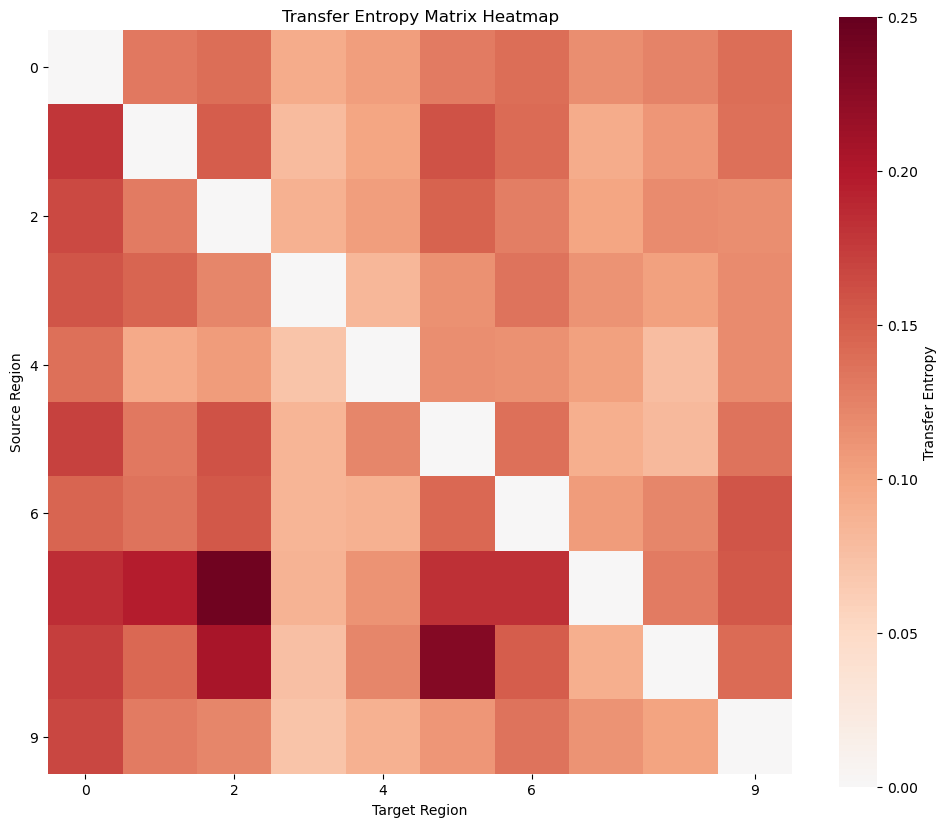

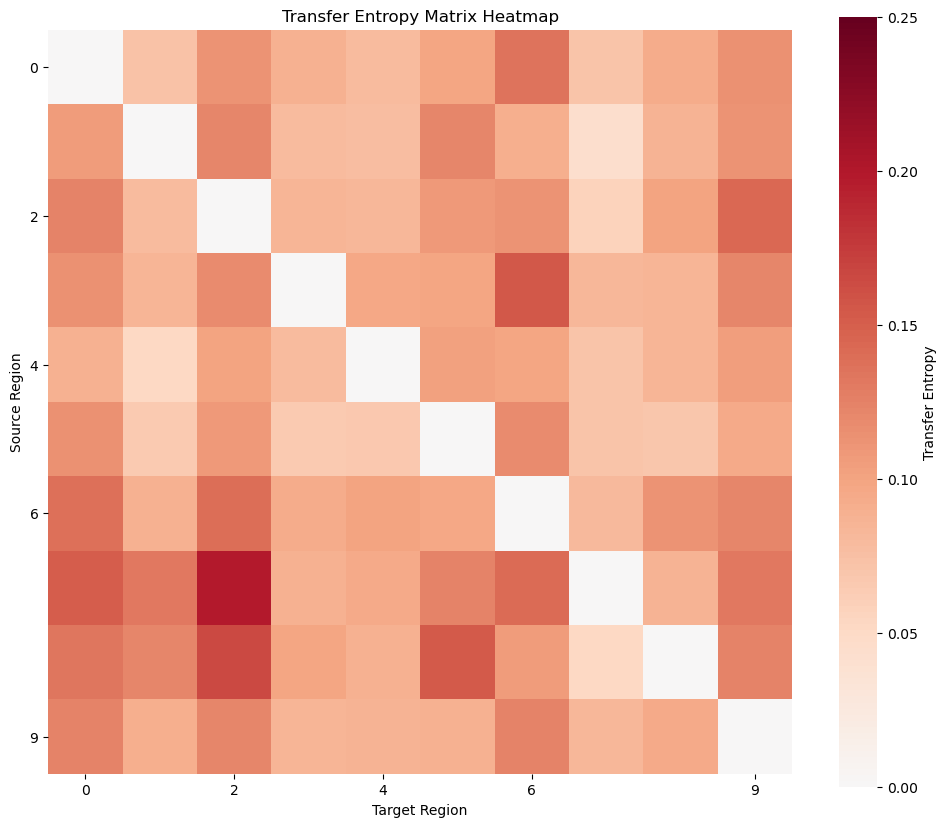

<Axes: title={'center': 'Transfer Entropy Matrix Heatmap'}, xlabel='Target Region', ylabel='Source Region'>

In [4]:
nbins = int(600**(1/3)) # We choose as Nbins 1/2*N^{1/3} --> heuristics
TE_real_bin_1 = nlib.transfer_entropy_matrix(data1_mat, n_bins=nbins, lag=1)
TE_real_bin_2 = nlib.transfer_entropy_matrix(data2_mat, n_bins=nbins, lag=1)
TE_heatMat(TE_real_bin_1, cmap="RdBu_r", figsize=(12,10))
TE_heatMat(TE_real_bin_2, cmap="RdBu_r", figsize=(12,10))

# Joint Gaussian assumption

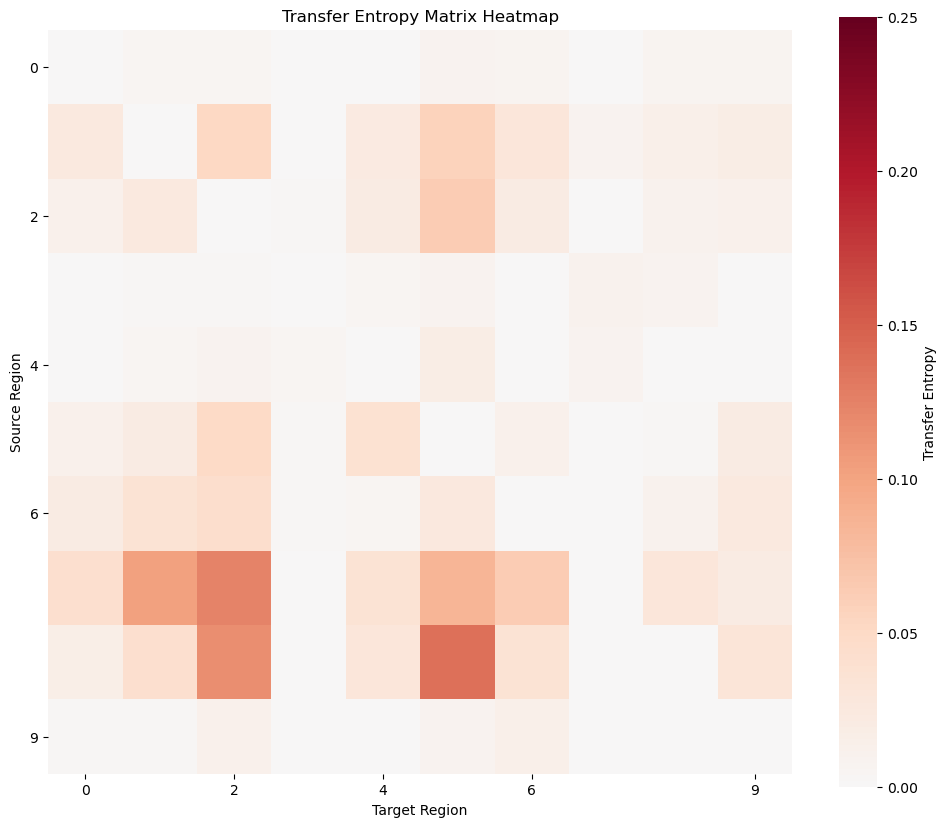

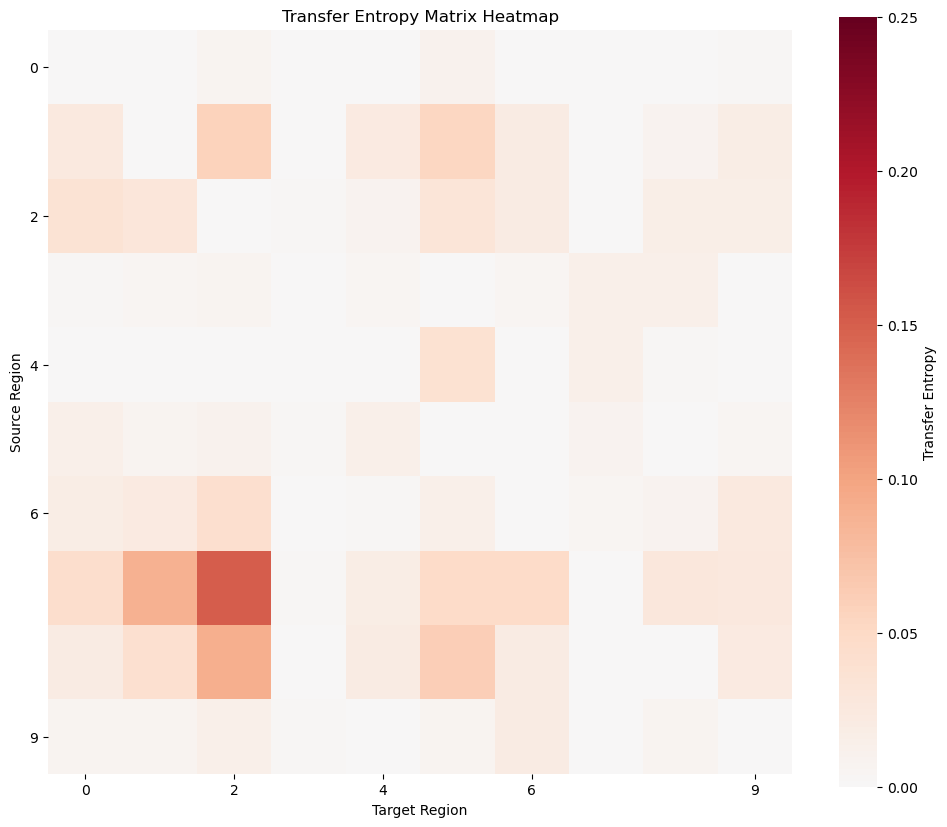

<Axes: title={'center': 'Transfer Entropy Matrix Heatmap'}, xlabel='Target Region', ylabel='Source Region'>

In [5]:
TE_real_gauss_1 = nlib.transfer_entropy_matrix(data1_mat, method = "gauss", lag=1)
TE_real_gauss_2 = nlib.transfer_entropy_matrix(data2_mat, method = "gauss", lag=1)
TE_heatMat(TE_real_gauss_1, cmap="RdBu_r", figsize=(12,10))
TE_heatMat(TE_real_gauss_2, cmap="RdBu_r",  figsize=(12,10))

# KDE method

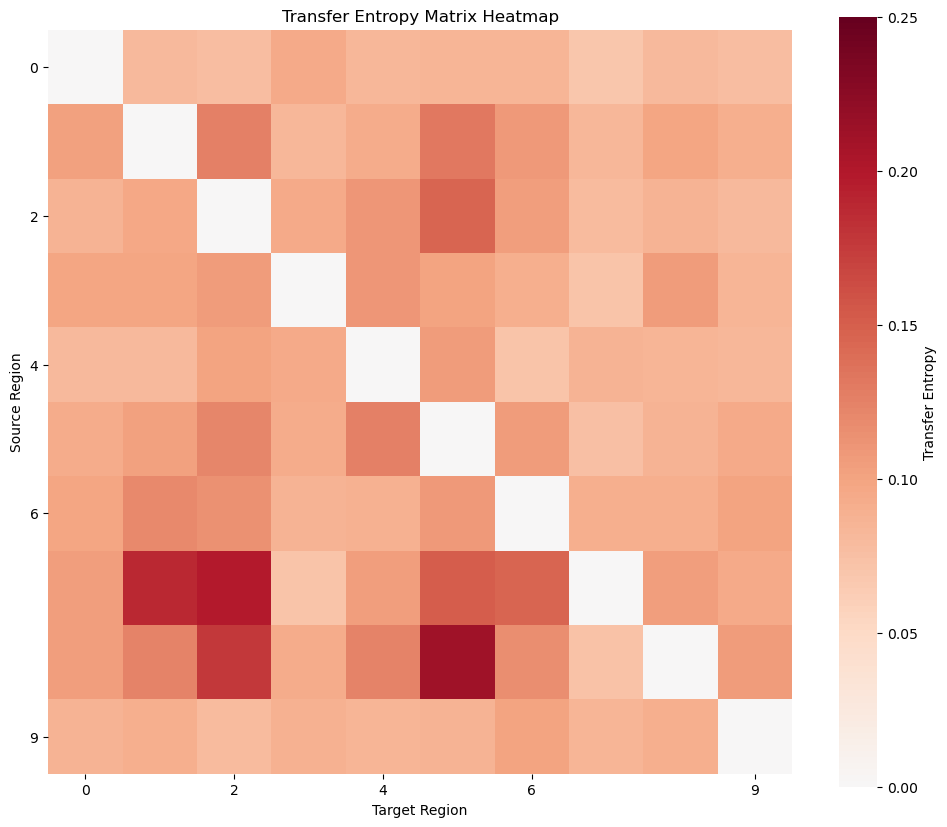

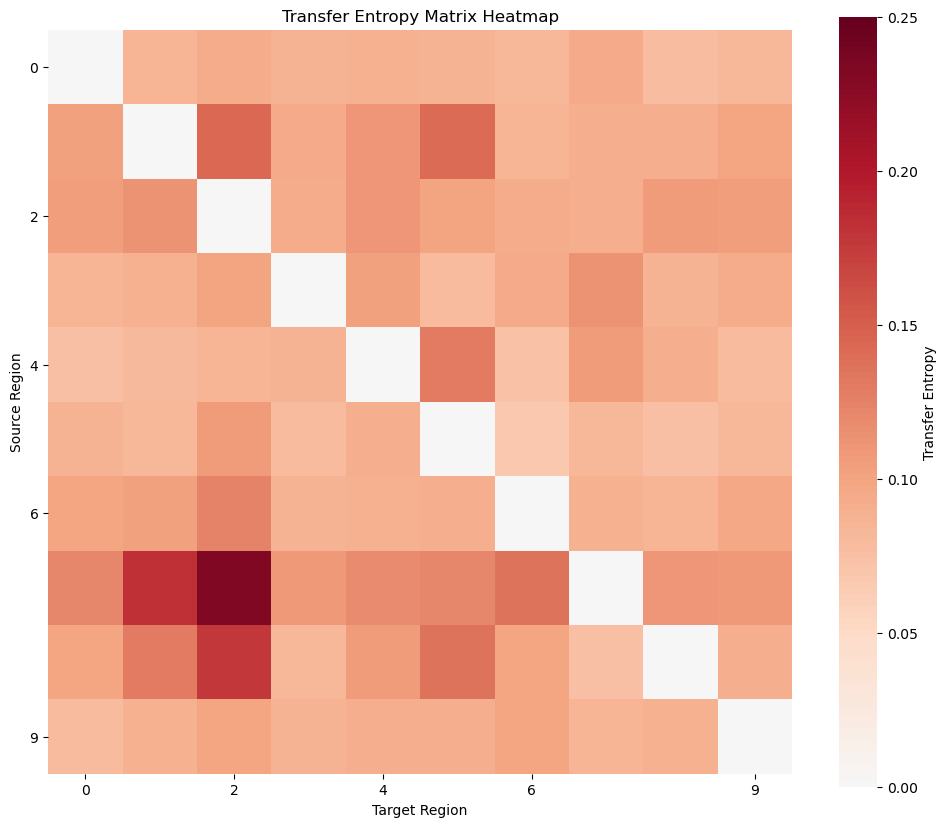

<Axes: title={'center': 'Transfer Entropy Matrix Heatmap'}, xlabel='Target Region', ylabel='Source Region'>

In [6]:
# NOTICE: on full data is VERY SLOW - KDE scales very badly with both sample 
#         size and dimensionality --> we reduce analysis to first 10 brain regions
TE_real_kde_1 = nlib.transfer_entropy_matrix(data1_mat, method="kde", alpha=1.0)
TE_real_kde_2 = nlib.transfer_entropy_matrix(data2_mat, method="kde", alpha=1.0)

TE_heatMat(TE_real_kde_1, cmap="RdBu_r", figsize=(12,10))
TE_heatMat(TE_real_kde_2, cmap="RdBu_r", figsize=(12,10))

# Gaussian Copula Method

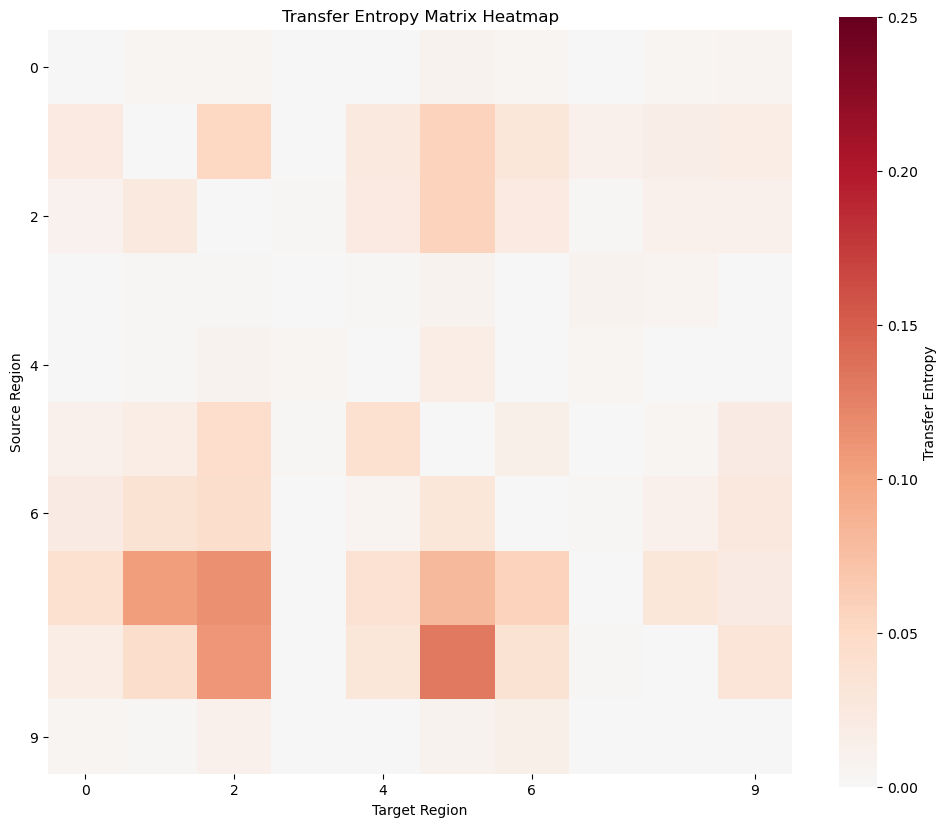

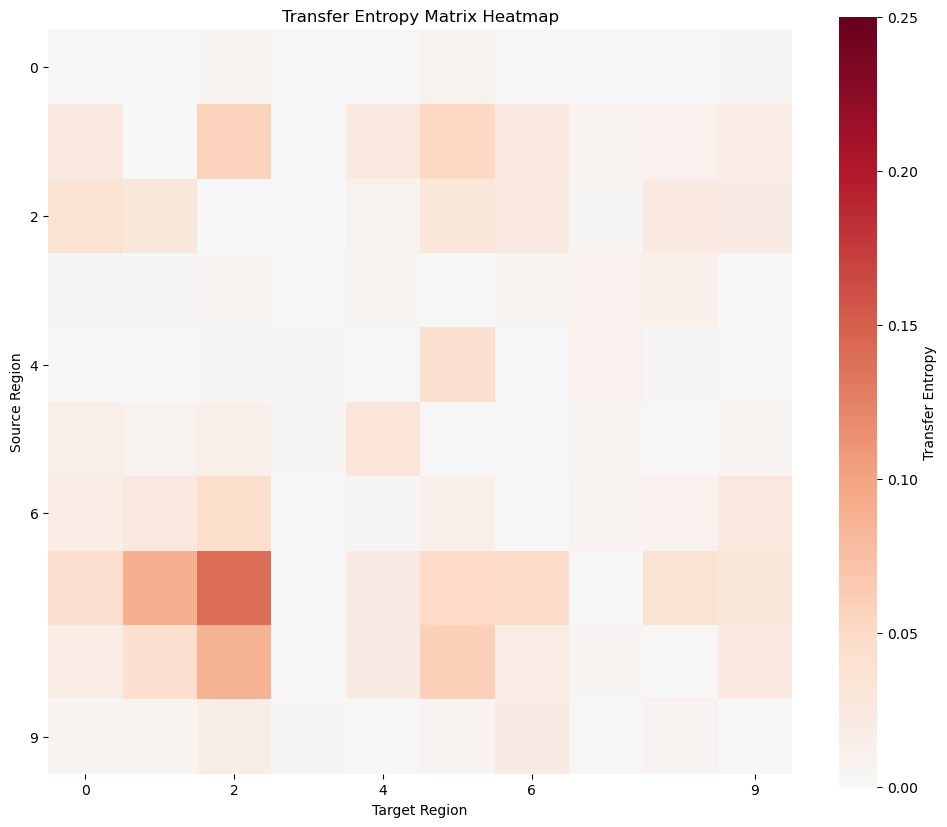

<Axes: title={'center': 'Transfer Entropy Matrix Heatmap'}, xlabel='Target Region', ylabel='Source Region'>

In [7]:
TE_real_copula_1 = nlib.transfer_entropy_matrix(data1_mat, method="gc")
TE_real_copula_2 = nlib.transfer_entropy_matrix(data2_mat, method="gc")

TE_heatMat(TE_real_copula_1, cmap="RdBu_r", figsize=(12,10))
TE_heatMat(TE_real_copula_2, cmap="RdBu_r", figsize=(12,10))

# **ANALYSIS** - **NULL DISTRIBUTION & HYPOTHESIS TESTING**
We remove FDR correction for this smaller dataset!

In [8]:
# PARAMETERS — shared across all methods and sessions

# General parameters for TE computation
lag = 1
kde_regions = 10
nbins = int(600**(1/3))
# Parameters for permutation testing
n_perms = 10
alpha   = 0.05   # significance threshold (5% → 95% confidence)

In [9]:
# Session 1 — Gaussian
# TE_real_gauss_1 was already computed above, we pass it directly
print("Session 1 — Gaussian")
sig_gauss_1, p_gauss_1, null95_gauss_1 = permutation_test_TE(
    data1_mat, TE_real_gauss_1, method="gauss",
    n_perms=n_perms, alpha=alpha, fdr=False, lag=lag)

# Session 1 — Copula
print("\nSession 1 — Copula")
sig_copula_1, p_copula_1, null95_copula_1 = permutation_test_TE(
    data1_mat, TE_real_copula_1, method="gc",
    n_perms=n_perms, alpha=alpha, fdr=False, lag=lag)

# Session 1 — Binning
print("\nSession 1 — Binning")
sig_bin_1, p_bin_1, null95_bin_1 = permutation_test_TE(
    data1_mat, TE_real_bin_1, method="binning",
    n_perms=n_perms, alpha=alpha, fdr=False, lag=lag, n_bins=nbins)

# Session 1 — KDE (only first kde_regions regions)
print("\nSession 1 — KDE")
sig_kde_1, p_kde_1, null95_kde_1 = permutation_test_TE(
    data1_mat[:kde_regions, :], TE_real_kde_1, method="kde",
    n_perms=n_perms, alpha=alpha, fdr=False, lag=lag)

Session 1 — Gaussian
  [gauss] shuffle 0/10...
  → 68 significant connections (uncorrected, α=0.05)

Session 1 — Copula
  [gc] shuffle 0/10...
  → 69 significant connections (uncorrected, α=0.05)

Session 1 — Binning
  [binning] shuffle 0/10...
  → 5 significant connections (uncorrected, α=0.05)

Session 1 — KDE
  [kde] shuffle 0/10...
  → 47 significant connections (uncorrected, α=0.05)


In [10]:
# Recompute real TE for session 2 
# (if you already have TE_real_gauss_2 etc. from earlier cells, skip these lines)
TE_real_gauss_2  = nlib.transfer_entropy_matrix(data2_mat, method="gauss", lag=lag)
TE_real_copula_2 = nlib.transfer_entropy_matrix(data2_mat, method="gc",   lag=lag)
TE_real_bin_2    = nlib.transfer_entropy_matrix(data2_mat, method="binning",  lag=lag, n_bins=nbins)
TE_real_kde_2    = nlib.transfer_entropy_matrix(data2_mat[:kde_regions, :], method="kde", lag=lag)

print("Session 2 — Gaussian")
sig_gauss_2, p_gauss_2, null95_gauss_2 = permutation_test_TE(
    data2_mat, TE_real_gauss_2, method="gauss",
    n_perms=n_perms, alpha=alpha, fdr=False, lag=lag)

print("\nSession 2 — Copula")
sig_copula_2, p_copula_2, null95_copula_2 = permutation_test_TE(
    data2_mat, TE_real_copula_2, method="gc",
    n_perms=n_perms, alpha=alpha, fdr=False, lag=lag)

print("\nSession 2 — Binning")
sig_bin_2, p_bin_2, null95_bin_2 = permutation_test_TE(
    data2_mat, TE_real_bin_2, method="binning",
    n_perms=n_perms, alpha=alpha, fdr=False, lag=lag, n_bins=nbins)

print("\nSession 2 — KDE")
sig_kde_2, p_kde_2, null95_kde_2 = permutation_test_TE(
    data2_mat[:kde_regions, :], TE_real_kde_2, method="kde",
    n_perms=n_perms, alpha=alpha, fdr=False, lag=lag)

Session 2 — Gaussian
  [gauss] shuffle 0/10...
  → 67 significant connections (uncorrected, α=0.05)

Session 2 — Copula
  [gc] shuffle 0/10...
  → 64 significant connections (uncorrected, α=0.05)

Session 2 — Binning
  [binning] shuffle 0/10...
  → 3 significant connections (uncorrected, α=0.05)

Session 2 — KDE
  [kde] shuffle 0/10...
  → 41 significant connections (uncorrected, α=0.05)


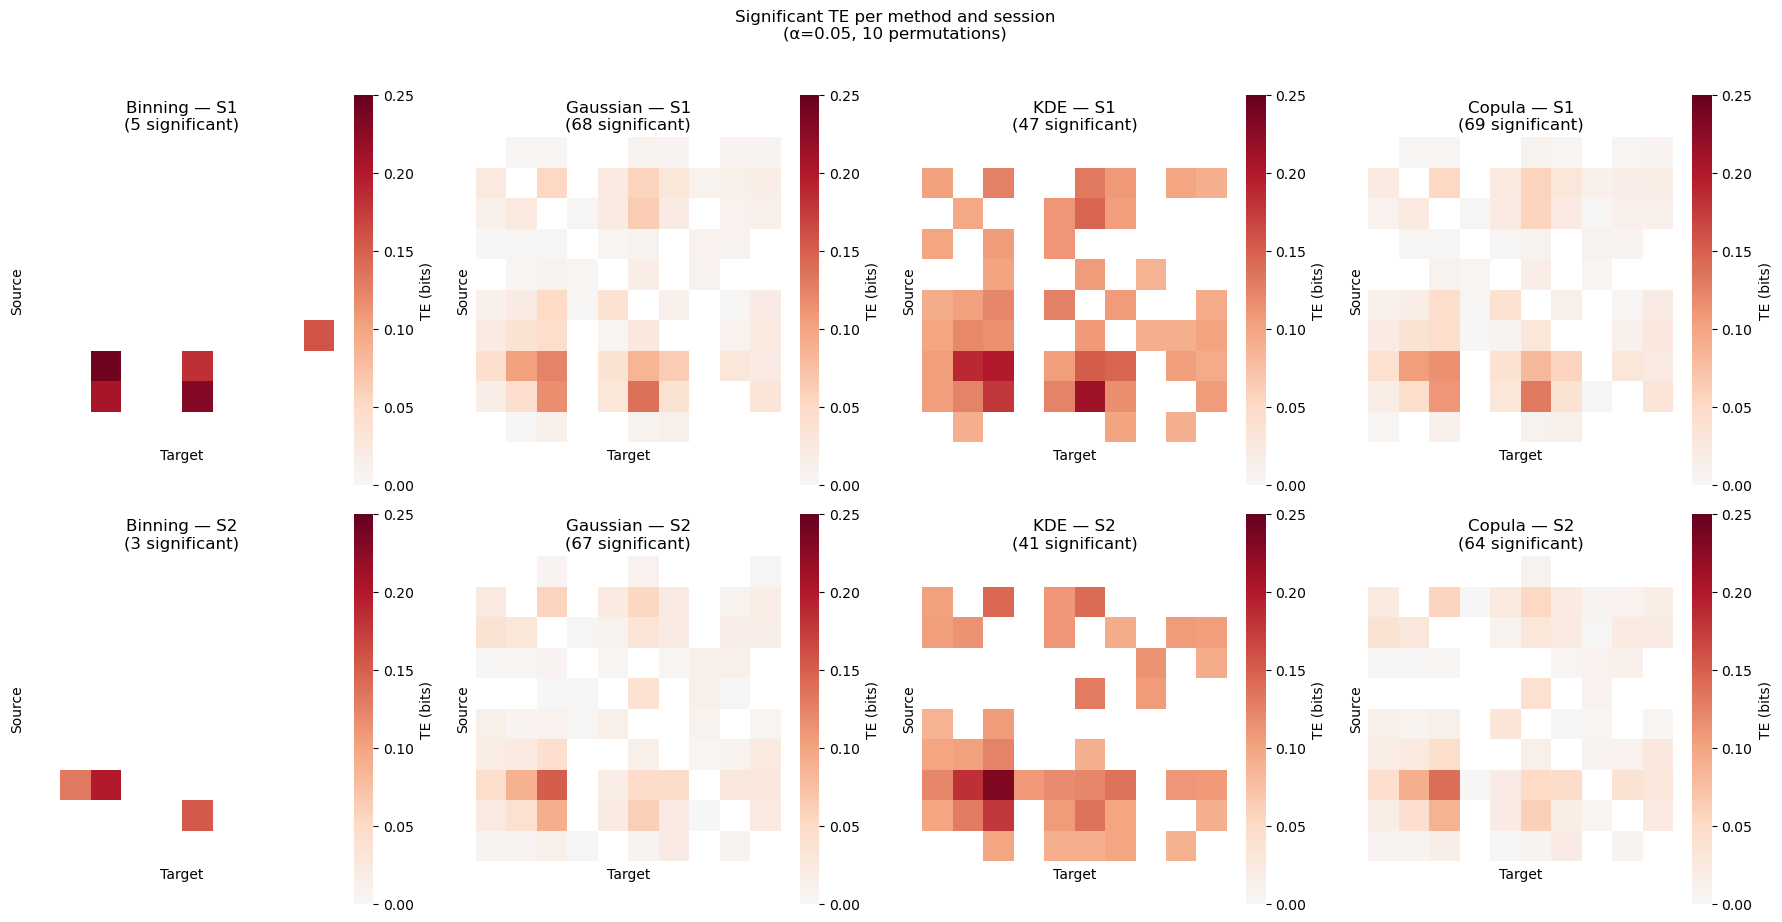

Robust connections surviving both sessions (α=0.05, 10 permutations):
Method           S1     S2   Both
--------------------------------
Binning           5      3      2
Gaussian         68     67     59
KDE              47     41     31
Copula           69     64     55


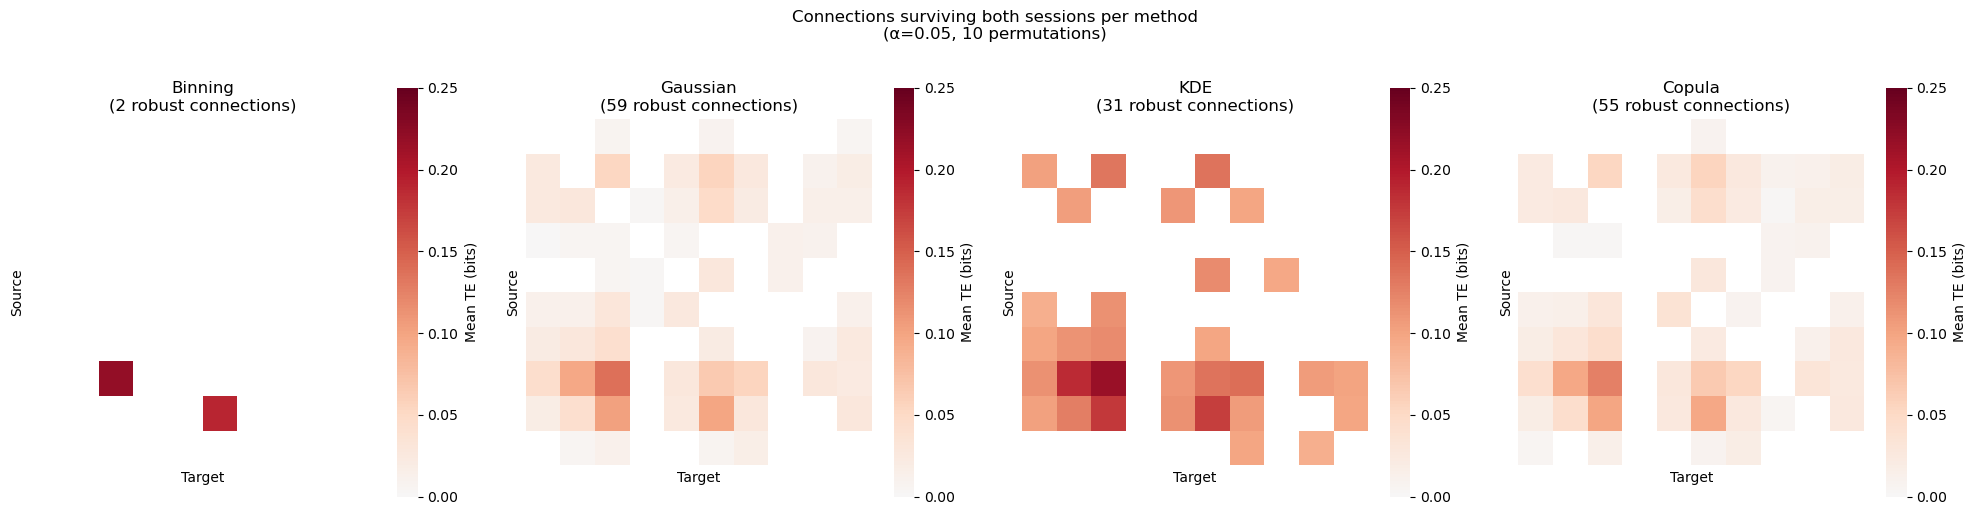

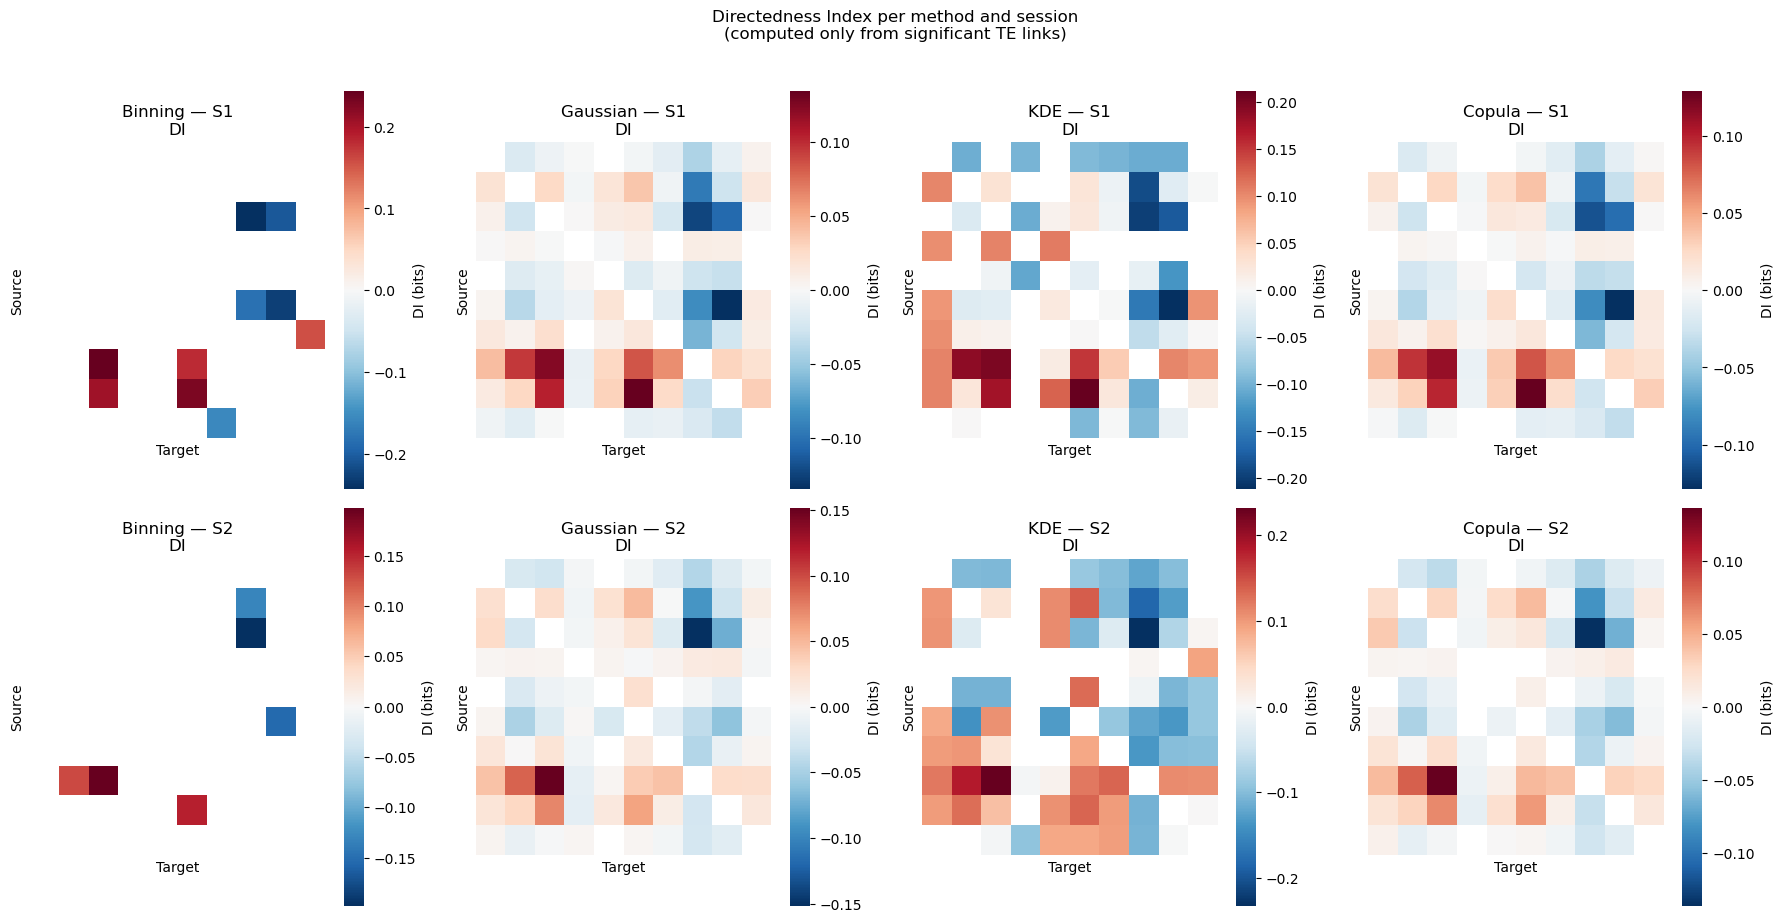

In [11]:
# --------------------------------------------------
# TEs per method, per session
# 2 rows (sessions) x 4 columns (methods)
# --------------------------------------------------
fig, axes = plt.subplots(2, 4, figsize=(18, 9))

sig_grid = [
    # Session 1
    (sig_bin_1,    TE_real_bin_1,    "Binning — S1"),
    (sig_gauss_1,  TE_real_gauss_1,  "Gaussian — S1"),
    (sig_kde_1,    TE_real_kde_1,    "KDE — S1"),
    (sig_copula_1, TE_real_copula_1, "Copula — S1"),
    # Session 2
    (sig_bin_2,    TE_real_bin_2,    "Binning — S2"),
    (sig_gauss_2,  TE_real_gauss_2,  "Gaussian — S2"),
    (sig_kde_2,    TE_real_kde_2,    "KDE — S2"),
    (sig_copula_2, TE_real_copula_2, "Copula — S2"),
]

for ax, (sig, te, title) in zip(axes.flat, sig_grid):
    # Keep real TE values only where significant, NaN elsewhere
    te_masked = np.where(sig, te, np.nan)
    sns.heatmap(te_masked, ax=ax, cmap="RdBu_r",
                center=0, square=True, vmin = 0, vmax = 0.25,
                cbar_kws={"label": "TE (bits)"},
                xticklabels=False, yticklabels=False)
    ax.set_title(f"{title}\n({sig.sum()} significant)")
    ax.set_xlabel("Target")
    ax.set_ylabel("Source")

plt.suptitle(f"Significant TE per method and session\n"
             f"(α={alpha}, {n_perms} permutations)", y=1.02)
plt.tight_layout()
plt.show()

# --------------------------------------------------
# Robust TEs across sessions (averaged between sessions)
# 4 columns (methods)
# --------------------------------------------------
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

methods_grid = [
    (sig_bin_1,    sig_bin_2,    TE_real_bin_1,    TE_real_bin_2,    "Binning"),
    (sig_gauss_1,  sig_gauss_2,  TE_real_gauss_1,  TE_real_gauss_2,  "Gaussian"),
    (sig_kde_1,    sig_kde_2,    TE_real_kde_1,    TE_real_kde_2,    "KDE"),
    (sig_copula_1, sig_copula_2, TE_real_copula_1, TE_real_copula_2, "Copula"),
]

# --- Summary ---
print(f"Robust connections surviving both sessions (α={alpha}, {n_perms} permutations):")
print(f"{'Method':<12} {'S1':>6} {'S2':>6} {'Both':>6}")
print("-" * 32)
for sig1, sig2, te1, te2, name in methods_grid:
    robust = sig1 & sig2
    np.fill_diagonal(robust, False)
    print(f"{name:<12} {sig1.sum():>6} {sig2.sum():>6} {robust.sum():>6}")

# --- Heatmaps ---
for ax, (sig1, sig2, te1, te2, name) in zip(axes, methods_grid):
    robust = sig1 & sig2
    np.fill_diagonal(robust, False)
    avg_te = np.where(robust, (te1 + te2) / 2, np.nan)

    sns.heatmap(avg_te, ax=ax, cmap="RdBu_r", center=0, square=True, vmin = 0, vmax = 0.25,
                cbar_kws={"label": "Mean TE (bits)"},
                xticklabels=False, yticklabels=False)
    ax.set_title(f"{name}\n({robust.sum()} robust connections)")
    ax.set_xlabel("Target")
    ax.set_ylabel("Source")

plt.suptitle(f"Connections surviving both sessions per method\n"
             f"(α={alpha}, {n_perms} permutations)", y=1.02)
plt.tight_layout()
plt.show()

# --- Detailed pair list (comment out if not needed) ---
"""
for sig1, sig2, te1, te2, name in methods_grid:
    robust = sig1 & sig2
    np.fill_diagonal(robust, False)
    rows, cols = np.where(robust)

    print(f"\n{'='*50}")
    print(f"{name} — {robust.sum()} connections surviving both sessions:")
    print(f"{'Source':>8} {'Target':>8} | {'TE S1':>10} {'TE S2':>10} {'Mean TE':>10}")
    print("-" * 50)
    for i, j in zip(rows, cols):
        mean_te = (te1[i,j] + te2[i,j]) / 2
        print(f"{i:>8} {j:>8} | {te1[i,j]:>10.4f} {te2[i,j]:>10.4f} {mean_te:>10.4f}")
"""

# --------------------------------------------------
# Directedness Index (DI) per method, per session
# DI[i,j] = TE[i,j] - TE[j,i]
# 2 rows (sessions) x 4 columns (methods)
# --------------------------------------------------

fig, axes = plt.subplots(2, 4, figsize=(18, 9))

for ax, (sig, te, title) in zip(axes.flat, sig_grid):

    # Keep only significant TE values
    te_sig = np.where(sig, te, 0.0)

    # Directedness Index
    DI = te_sig - te_sig.T

    # Hide zero entries
    DI_masked = np.where(DI != 0, DI, np.nan)

    sns.heatmap(
        DI_masked,
        ax=ax,
        cmap="RdBu_r",
        center=0,
        square=True,
        cbar_kws={"label": "DI (bits)"},
        xticklabels=False,
        yticklabels=False
    )

    ax.set_title(f"{title}\nDI")
    ax.set_xlabel("Target")
    ax.set_ylabel("Source")

plt.suptitle(f"Directedness Index per method and session\n"
             f"(computed only from significant TE links)", y=1.02)
plt.tight_layout()
plt.show()

# **CONSENSUS MATRIX**

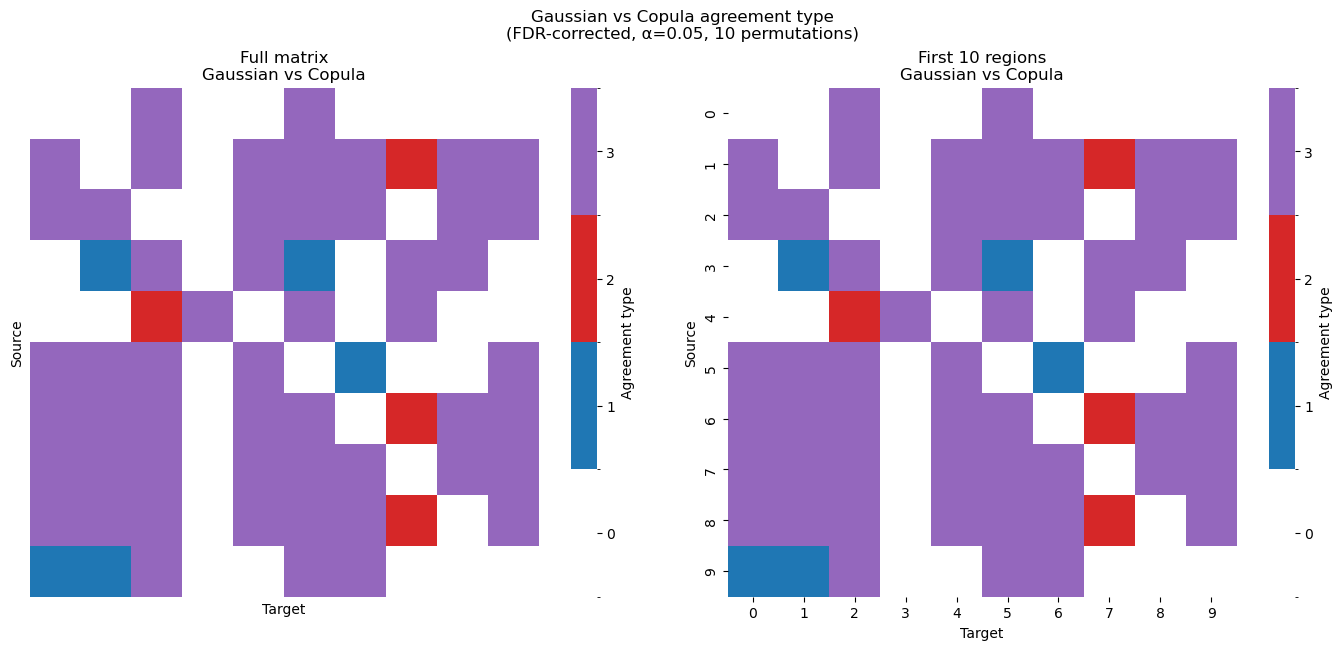

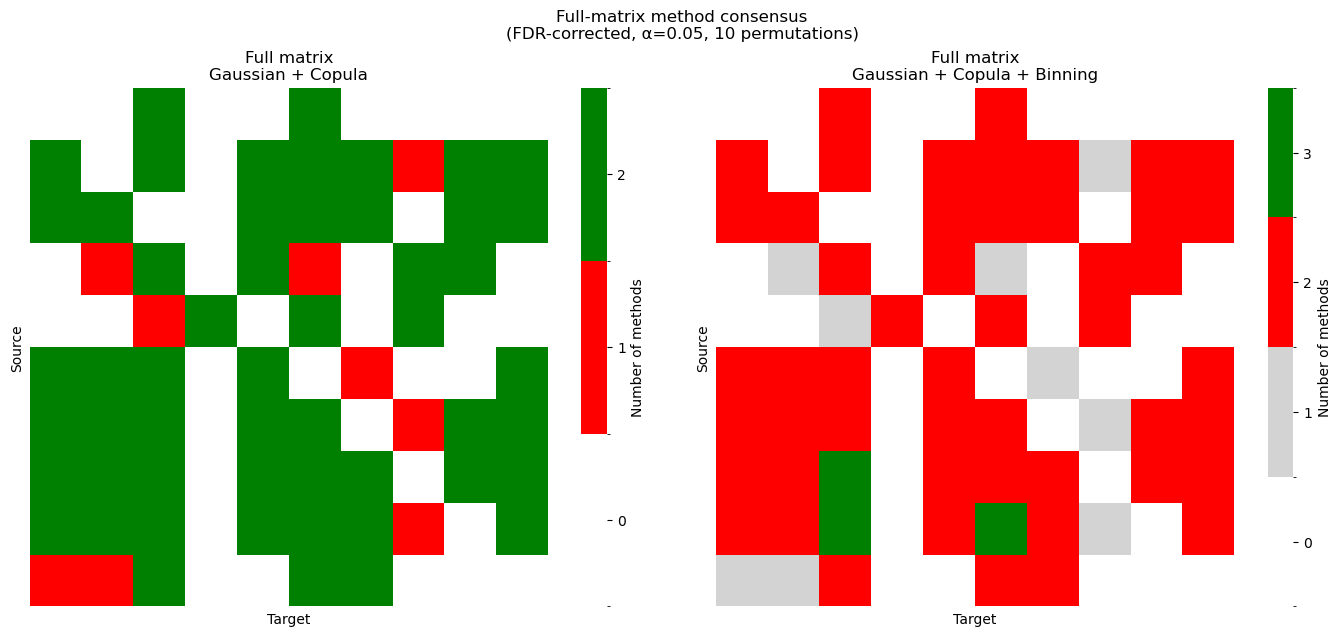

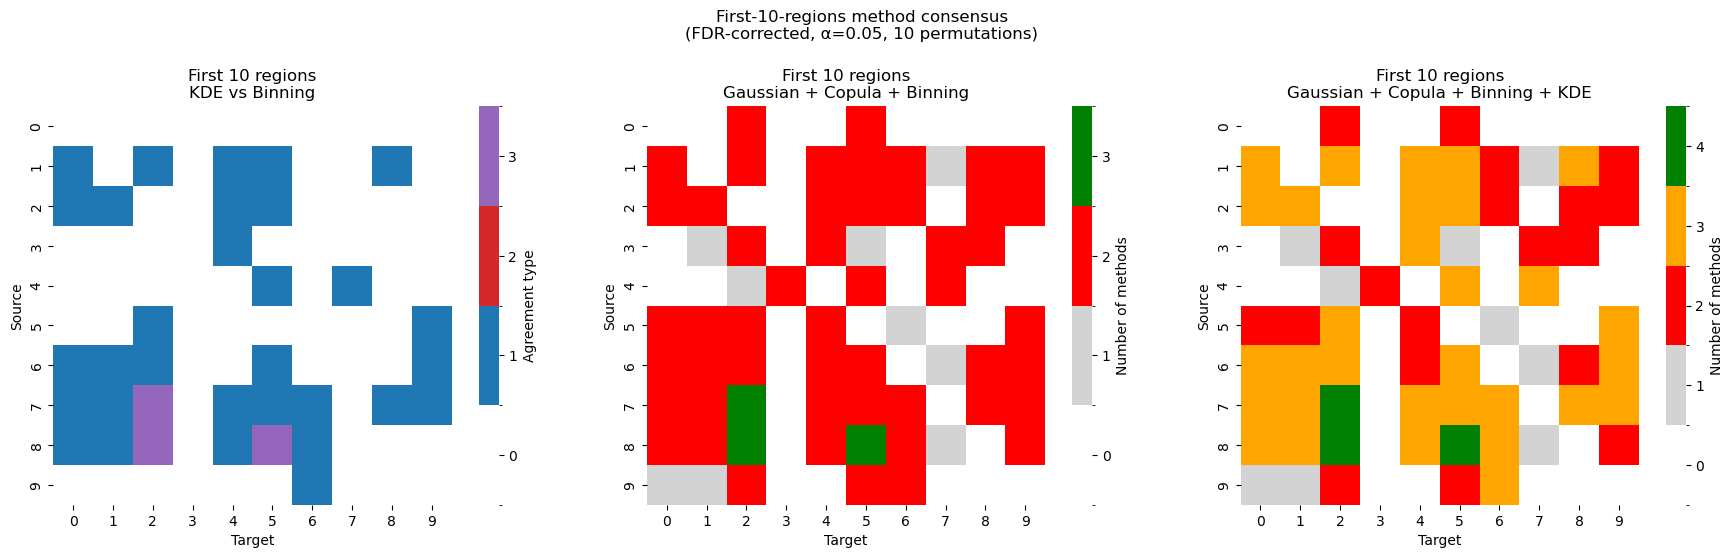

Gaussian vs Copula — full matrix:
  Gaussian only :   8.06%
  Copula only   :   6.45%
  Both          :  85.48%
  Total detected links: 62

Gaussian vs Copula — first 10 regions:
  Gaussian only :   8.06%
  Copula only   :   6.45%
  Both          :  85.48%
  Total detected links: 62

Full matrix — Gaussian + Copula:
  1 methods agree:  14.52%
  2 methods agree:  85.48%
  Total detected links: 62

Full matrix — Gaussian + Copula + Binning:
  1 methods agree:  14.52%
  2 methods agree:  80.65%
  3 methods agree:   4.84%
  Total detected links: 62

First 10 — KDE vs Binning:
  KDE only      :  91.18%
  Binning only  :   0.00%
  Both          :   8.82%
  Total detected links: 34

First 10 — Gaussian + Copula:
  1 methods agree:  14.52%
  2 methods agree:  85.48%
  Total detected links: 62

First 10 — Gaussian + Copula + Binning:
  1 methods agree:  14.52%
  2 methods agree:  80.65%
  3 methods agree:   4.84%
  Total detected links: 62

First 10 — all methods:
  1 methods agree:  14.52%
  2

In [39]:
# --------------------------------------------------
# Consensus matrices:
# Figure 0: Gaussian vs Copula agreement type
# Figure 1: full 119x119 matrix
# Figure 2: first 10 regions, progressively adding methods
# --------------------------------------------------

from matplotlib.colors import ListedColormap, BoundaryNorm

# --- Robust links: keep only links significant in both sessions ---
robust_bin    = sig_bin_1    & sig_bin_2;    np.fill_diagonal(robust_bin,    False)
robust_gauss  = sig_gauss_1  & sig_gauss_2;  np.fill_diagonal(robust_gauss,  False)
robust_copula = sig_copula_1 & sig_copula_2; np.fill_diagonal(robust_copula, False)
robust_kde    = sig_kde_1    & sig_kde_2;    np.fill_diagonal(robust_kde,    False)

# --------------------------------------------------
# Gaussian vs Copula categorical agreement map
# 0 = none, 1 = Gaussian only, 2 = Copula only, 3 = Both
# --------------------------------------------------

gc_type_full = robust_gauss.astype(int) + 2 * robust_copula.astype(int)

n = kde_regions
gc_type_10 = gc_type_full[:n, :n]

colors_gc_type = ["white", "#1f77b4", "#d62728", "#9467bd"]
cmap_gc_type = ListedColormap(colors_gc_type)
norm_gc_type = BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5], cmap_gc_type.N)

# ==================================================
# FIGURE 0 — GAUSSIAN VS COPULA AGREEMENT TYPE
# ==================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.heatmap(gc_type_full, ax=axes[0],
            cmap=cmap_gc_type, norm=norm_gc_type,
            square=True,
            cbar_kws={"ticks": [0, 1, 2, 3], "label": "Agreement type"},
            xticklabels=False, yticklabels=False)

axes[0].set_title("Full matrix\nGaussian vs Copula")
axes[0].set_xlabel("Target")
axes[0].set_ylabel("Source")

sns.heatmap(gc_type_10, ax=axes[1],
            cmap=cmap_gc_type, norm=norm_gc_type,
            square=True,
            cbar_kws={"ticks": [0, 1, 2, 3], "label": "Agreement type"},
            xticklabels=range(n), yticklabels=range(n))

axes[1].set_title("First 10 regions\nGaussian vs Copula")
axes[1].set_xlabel("Target")
axes[1].set_ylabel("Source")

plt.suptitle(f"Gaussian vs Copula agreement type\n(FDR-corrected, α={alpha}, {n_perms} permutations)", y=1.02)
plt.tight_layout()
plt.show()

# --------------------------------------------------
# Custom discrete colormap
# 0 = white, 1 = light grey, 2 = red, 3 = orange, 4 = green
# --------------------------------------------------

colors = ["white", "#D3D3D3", "#FF0000", "#FFA500", "#008000"]
cmap = ListedColormap(colors)

norm_2 = BoundaryNorm([-0.5, 0.5, 1.5, 2.5], cmap.N)
norm_3 = BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5], cmap.N)
norm_4 = BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5, 4.5], cmap.N)

# ==================================================
# FIGURE 1 — FULL MATRIX
# ==================================================

consensus_gc_full = (
    robust_gauss.astype(int) +
    robust_copula.astype(int)
)

consensus_gcb_full = (
    robust_gauss.astype(int) +
    robust_copula.astype(int) +
    robust_bin.astype(int)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.heatmap(consensus_gc_full, ax=axes[0],
            cmap=cmap, norm=norm_2,
            square=True,
            cbar_kws={"ticks": [0, 1, 2], "label": "Number of methods"},
            xticklabels=False, yticklabels=False)

axes[0].set_title("Full matrix\nGaussian + Copula")
axes[0].set_xlabel("Target")
axes[0].set_ylabel("Source")

sns.heatmap(consensus_gcb_full, ax=axes[1],
            cmap=cmap, norm=norm_3,
            square=True,
            cbar_kws={"ticks": [0, 1, 2, 3], "label": "Number of methods"},
            xticklabels=False, yticklabels=False)

axes[1].set_title("Full matrix\nGaussian + Copula + Binning")
axes[1].set_xlabel("Target")
axes[1].set_ylabel("Source")

plt.suptitle(f"Full-matrix method consensus\n(FDR-corrected, α={alpha}, {n_perms} permutations)", y=1.02)
plt.tight_layout()
plt.show()

# ==================================================
# FIGURE 2 — FIRST 10 REGIONS
# ==================================================

consensus_gc_10 = (
    robust_gauss[:n, :n].astype(int) +
    robust_copula[:n, :n].astype(int)
)

consensus_gcb_10 = (
    robust_gauss[:n, :n].astype(int) +
    robust_copula[:n, :n].astype(int) +
    robust_bin[:n, :n].astype(int)
)

consensus_all_10 = (
    robust_gauss[:n, :n].astype(int) +
    robust_copula[:n, :n].astype(int) +
    robust_bin[:n, :n].astype(int) +
    robust_kde.astype(int)
)

# --- NEW: KDE vs Binning categorical map (replacing previous left plot) ---
kb_type_10 = robust_kde.astype(int) + 2 * robust_bin[:n, :n].astype(int)

colors_kb_type = ["white", "#1f77b4", "#d62728", "#9467bd"]
cmap_kb_type = ListedColormap(colors_kb_type)
norm_kb_type = BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5], cmap_kb_type.N)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.heatmap(kb_type_10, ax=axes[0],
            cmap=cmap_kb_type, norm=norm_kb_type,
            square=True,
            cbar_kws={"ticks": [0, 1, 2, 3], "label": "Agreement type"},
            xticklabels=range(n), yticklabels=range(n))

axes[0].set_title("First 10 regions\nKDE vs Binning")
axes[0].set_xlabel("Target")
axes[0].set_ylabel("Source")

sns.heatmap(consensus_gcb_10, ax=axes[1],
            cmap=cmap, norm=norm_3,
            square=True,
            cbar_kws={"ticks": [0, 1, 2, 3], "label": "Number of methods"},
            xticklabels=range(n), yticklabels=range(n))

axes[1].set_title("First 10 regions\nGaussian + Copula + Binning")
axes[1].set_xlabel("Target")
axes[1].set_ylabel("Source")

sns.heatmap(consensus_all_10, ax=axes[2],
            cmap=cmap, norm=norm_4,
            square=True,
            cbar_kws={"ticks": [0, 1, 2, 3, 4], "label": "Number of methods"},
            xticklabels=range(n), yticklabels=range(n))

axes[2].set_title("First 10 regions\nGaussian + Copula + Binning + KDE")
axes[2].set_xlabel("Target")
axes[2].set_ylabel("Source")

plt.suptitle(f"First-10-regions method consensus\n(FDR-corrected, α={alpha}, {n_perms} permutations)", y=1.05)
plt.tight_layout()
plt.show()

# --------------------------------------------------
# Summary (percentages conditioned on detection)
# --------------------------------------------------

def print_percentages_conditioned(matrix, name, max_k):
    # exclude diagonal
    mask_offdiag = ~np.eye(matrix.shape[0], dtype=bool)
    values = matrix[mask_offdiag]

    # condition on at least one method detecting the link
    detected = values > 0
    total_detected = np.sum(detected)

    print(name)

    if total_detected == 0:
        print("  No detected links.\n")
        return

    for k in range(1, max_k + 1):  # start from 1 (ignore zero)
        count = np.sum(values == k)
        perc = 100 * count / total_detected
        print(f"  {k} methods agree: {perc:6.2f}%")

    print(f"  Total detected links: {total_detected}\n")


def print_gc_type_conditioned(matrix, name):
    mask_offdiag = ~np.eye(matrix.shape[0], dtype=bool)
    values = matrix[mask_offdiag]

    # detected by at least one method (Gaussian or Copula)
    detected = values > 0
    total_detected = np.sum(detected)

    print(name)

    if total_detected == 0:
        print("  No detected links.\n")
        return

    labels = ["Gaussian only", "Copula only", "Both"]
    for k, lab in zip([1, 2, 3], labels):
        count = np.sum(values == k)
        perc = 100 * count / total_detected
        print(f"  {lab:<14}: {perc:6.2f}%")

    print(f"  Total detected links: {total_detected}\n")


def print_kb_type_conditioned(matrix, name):
    mask_offdiag = ~np.eye(matrix.shape[0], dtype=bool)
    values = matrix[mask_offdiag]

    # detected by at least one method (KDE or Binning)
    detected = values > 0
    total_detected = np.sum(detected)

    print(name)

    if total_detected == 0:
        print("  No detected links.\n")
        return

    labels = ["KDE only", "Binning only", "Both"]
    for k, lab in zip([1, 2, 3], labels):
        count = np.sum(values == k)
        perc = 100 * count / total_detected
        print(f"  {lab:<14}: {perc:6.2f}%")

    print(f"  Total detected links: {total_detected}\n")


# --- Gaussian vs Copula ---
print_gc_type_conditioned(gc_type_full, "Gaussian vs Copula — full matrix:")
print_gc_type_conditioned(gc_type_10, "Gaussian vs Copula — first 10 regions:")

# --- Full matrix ---
print_percentages_conditioned(consensus_gc_full, "Full matrix — Gaussian + Copula:", 2)
print_percentages_conditioned(consensus_gcb_full, "Full matrix — Gaussian + Copula + Binning:", 3)

# --- First 10 regions ---
print_kb_type_conditioned(kb_type_10, "First 10 — KDE vs Binning:")
print_percentages_conditioned(consensus_gc_10, "First 10 — Gaussian + Copula:", 2)
print_percentages_conditioned(consensus_gcb_10, "First 10 — Gaussian + Copula + Binning:", 3)
print_percentages_conditioned(consensus_all_10, "First 10 — all methods:", 4)

# **LAG SWEEP**

We analyze how the inferred connectivity depends on the **temporal lag** used in the Transfer Entropy computation.


LAG = 1
  [gauss] shuffle 0/10...
  → 65 significant connections (uncorrected, α=0.05)
  [gauss] shuffle 0/10...
  → 69 significant connections (uncorrected, α=0.05)
  [gc] shuffle 0/10...
  → 68 significant connections (uncorrected, α=0.05)
  [gc] shuffle 0/10...
  → 70 significant connections (uncorrected, α=0.05)
  [binning] shuffle 0/10...
  → 3 significant connections (uncorrected, α=0.05)
  [binning] shuffle 0/10...
  → 5 significant connections (uncorrected, α=0.05)
  [kde] shuffle 0/10...
  → 48 significant connections (uncorrected, α=0.05)
  [kde] shuffle 0/10...
  → 45 significant connections (uncorrected, α=0.05)


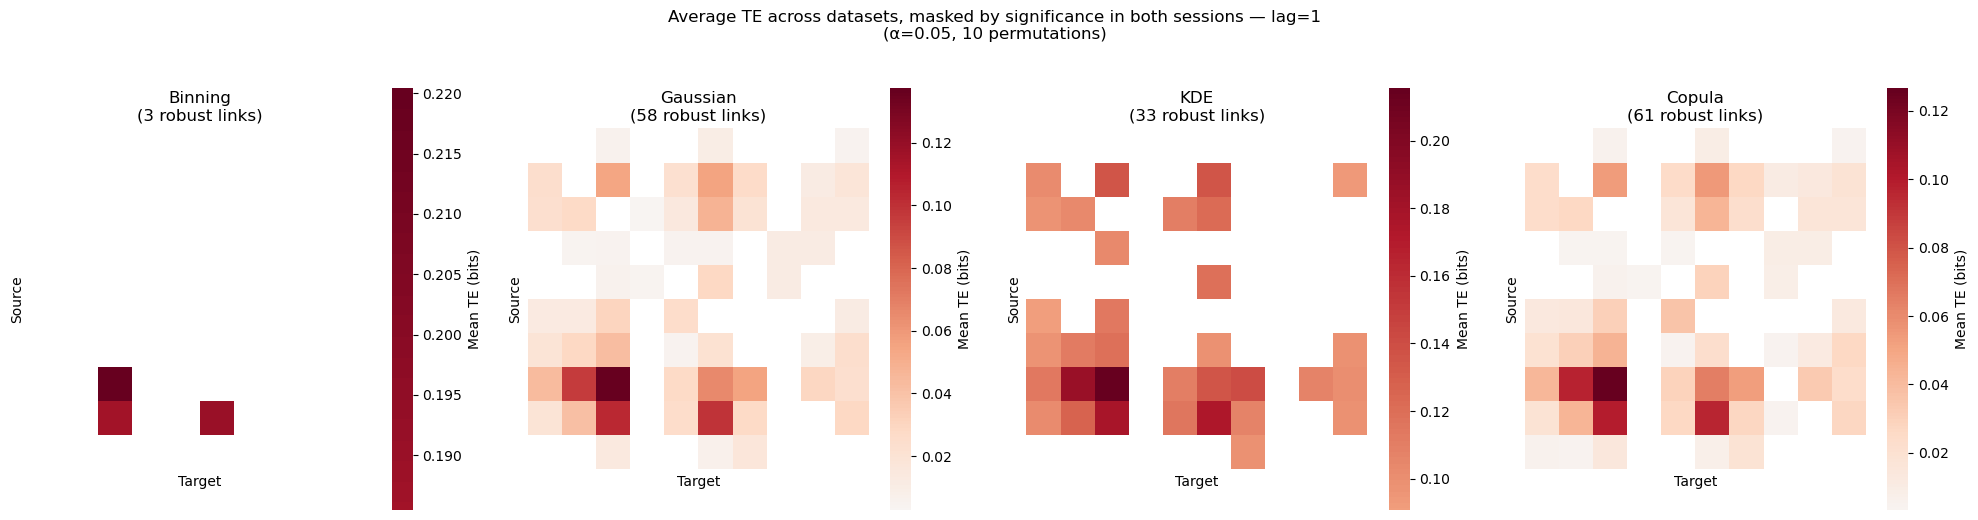


LAG = 2
  [gauss] shuffle 0/10...
  → 64 significant connections (uncorrected, α=0.05)
  [gauss] shuffle 0/10...
  → 65 significant connections (uncorrected, α=0.05)
  [gc] shuffle 0/10...
  → 58 significant connections (uncorrected, α=0.05)
  [gc] shuffle 0/10...
  → 63 significant connections (uncorrected, α=0.05)
  [binning] shuffle 0/10...
  → 1 significant connections (uncorrected, α=0.05)
  [binning] shuffle 0/10...
  → 0 significant connections (uncorrected, α=0.05)
  [kde] shuffle 0/10...
  → 39 significant connections (uncorrected, α=0.05)
  [kde] shuffle 0/10...
  → 30 significant connections (uncorrected, α=0.05)


/Users/giorgiafasiolo/opt/anaconda3/lib/python3.12/site-packages/seaborn/matrix.py:202: RuntimeWarning: All-NaN slice encountered
  vmin = np.nanmin(calc_data)
/Users/giorgiafasiolo/opt/anaconda3/lib/python3.12/site-packages/seaborn/matrix.py:207: RuntimeWarning: All-NaN slice encountered
  vmax = np.nanmax(calc_data)


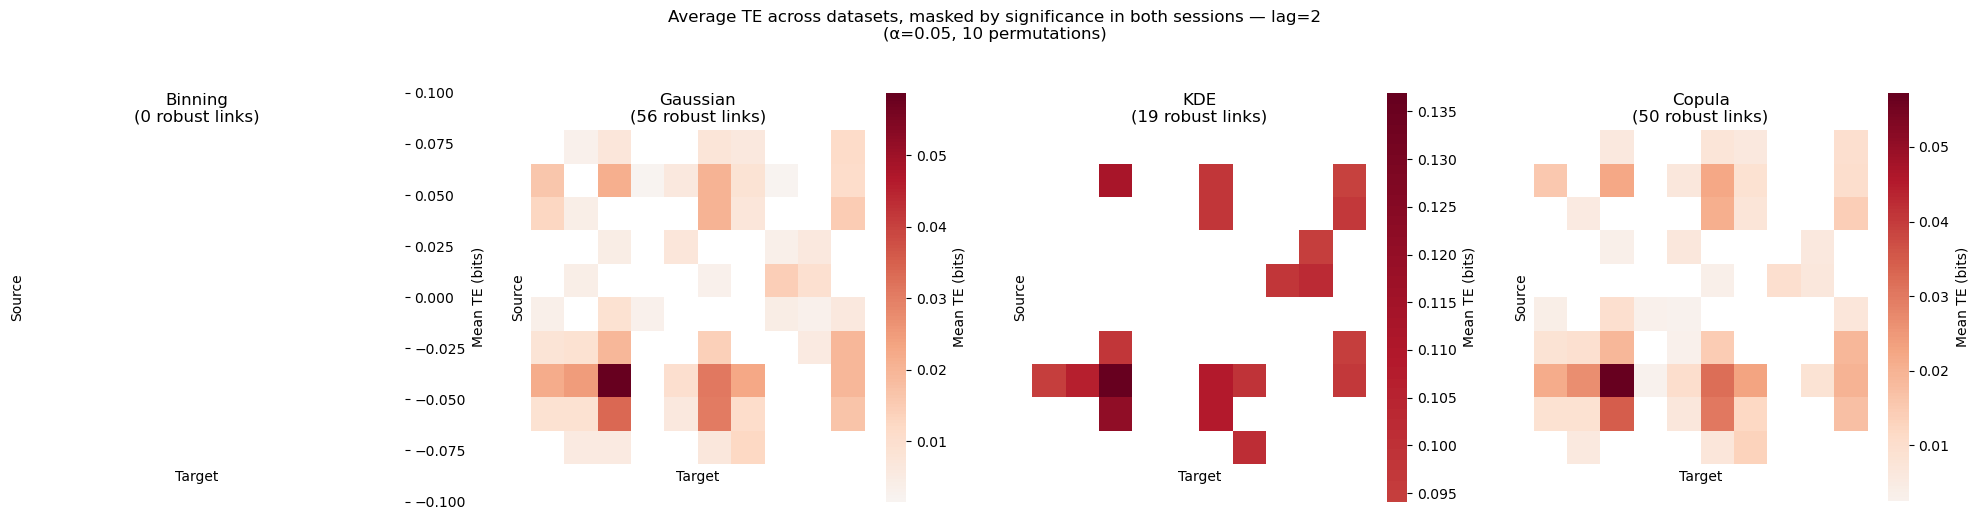


LAG = 5
  [gauss] shuffle 0/10...
  → 18 significant connections (uncorrected, α=0.05)
  [gauss] shuffle 0/10...
  → 33 significant connections (uncorrected, α=0.05)
  [gc] shuffle 0/10...
  → 16 significant connections (uncorrected, α=0.05)
  [gc] shuffle 0/10...
  → 41 significant connections (uncorrected, α=0.05)
  [binning] shuffle 0/10...
  → 0 significant connections (uncorrected, α=0.05)
  [binning] shuffle 0/10...
  → 0 significant connections (uncorrected, α=0.05)
  [kde] shuffle 0/10...
  → 10 significant connections (uncorrected, α=0.05)
  [kde] shuffle 0/10...
  → 14 significant connections (uncorrected, α=0.05)


/Users/giorgiafasiolo/opt/anaconda3/lib/python3.12/site-packages/seaborn/matrix.py:202: RuntimeWarning: All-NaN slice encountered
  vmin = np.nanmin(calc_data)
/Users/giorgiafasiolo/opt/anaconda3/lib/python3.12/site-packages/seaborn/matrix.py:207: RuntimeWarning: All-NaN slice encountered
  vmax = np.nanmax(calc_data)


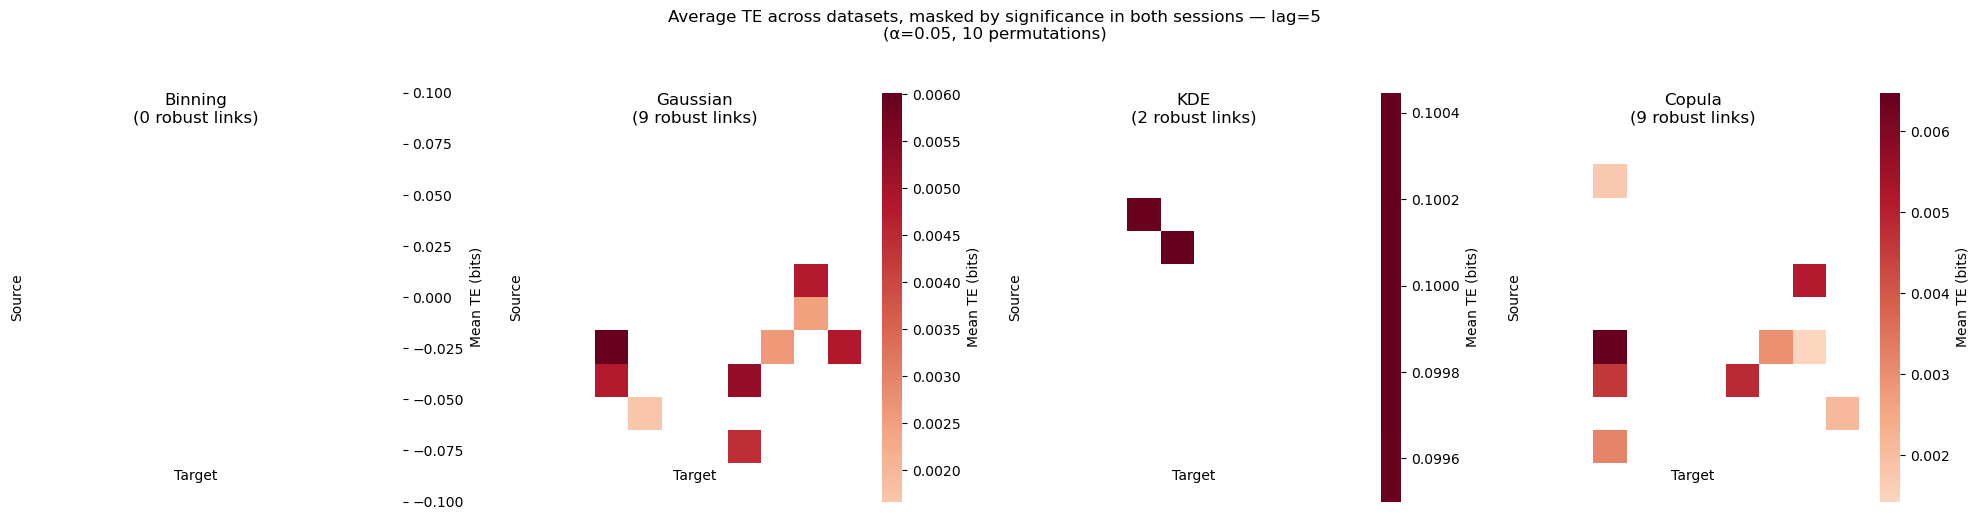


LAG = 10
  [gauss] shuffle 0/10...
  → 6 significant connections (uncorrected, α=0.05)
  [gauss] shuffle 0/10...
  → 15 significant connections (uncorrected, α=0.05)
  [gc] shuffle 0/10...
  → 5 significant connections (uncorrected, α=0.05)
  [gc] shuffle 0/10...
  → 17 significant connections (uncorrected, α=0.05)
  [binning] shuffle 0/10...
  → 0 significant connections (uncorrected, α=0.05)
  [binning] shuffle 0/10...
  → 0 significant connections (uncorrected, α=0.05)
  [kde] shuffle 0/10...
  → 3 significant connections (uncorrected, α=0.05)
  [kde] shuffle 0/10...
  → 8 significant connections (uncorrected, α=0.05)


/Users/giorgiafasiolo/opt/anaconda3/lib/python3.12/site-packages/seaborn/matrix.py:202: RuntimeWarning: All-NaN slice encountered
  vmin = np.nanmin(calc_data)
/Users/giorgiafasiolo/opt/anaconda3/lib/python3.12/site-packages/seaborn/matrix.py:207: RuntimeWarning: All-NaN slice encountered
  vmax = np.nanmax(calc_data)
/Users/giorgiafasiolo/opt/anaconda3/lib/python3.12/site-packages/seaborn/matrix.py:202: RuntimeWarning: All-NaN slice encountered
  vmin = np.nanmin(calc_data)
/Users/giorgiafasiolo/opt/anaconda3/lib/python3.12/site-packages/seaborn/matrix.py:207: RuntimeWarning: All-NaN slice encountered
  vmax = np.nanmax(calc_data)
/Users/giorgiafasiolo/opt/anaconda3/lib/python3.12/site-packages/seaborn/matrix.py:202: RuntimeWarning: All-NaN slice encountered
  vmin = np.nanmin(calc_data)
/Users/giorgiafasiolo/opt/anaconda3/lib/python3.12/site-packages/seaborn/matrix.py:207: RuntimeWarning: All-NaN slice encountered
  vmax = np.nanmax(calc_data)


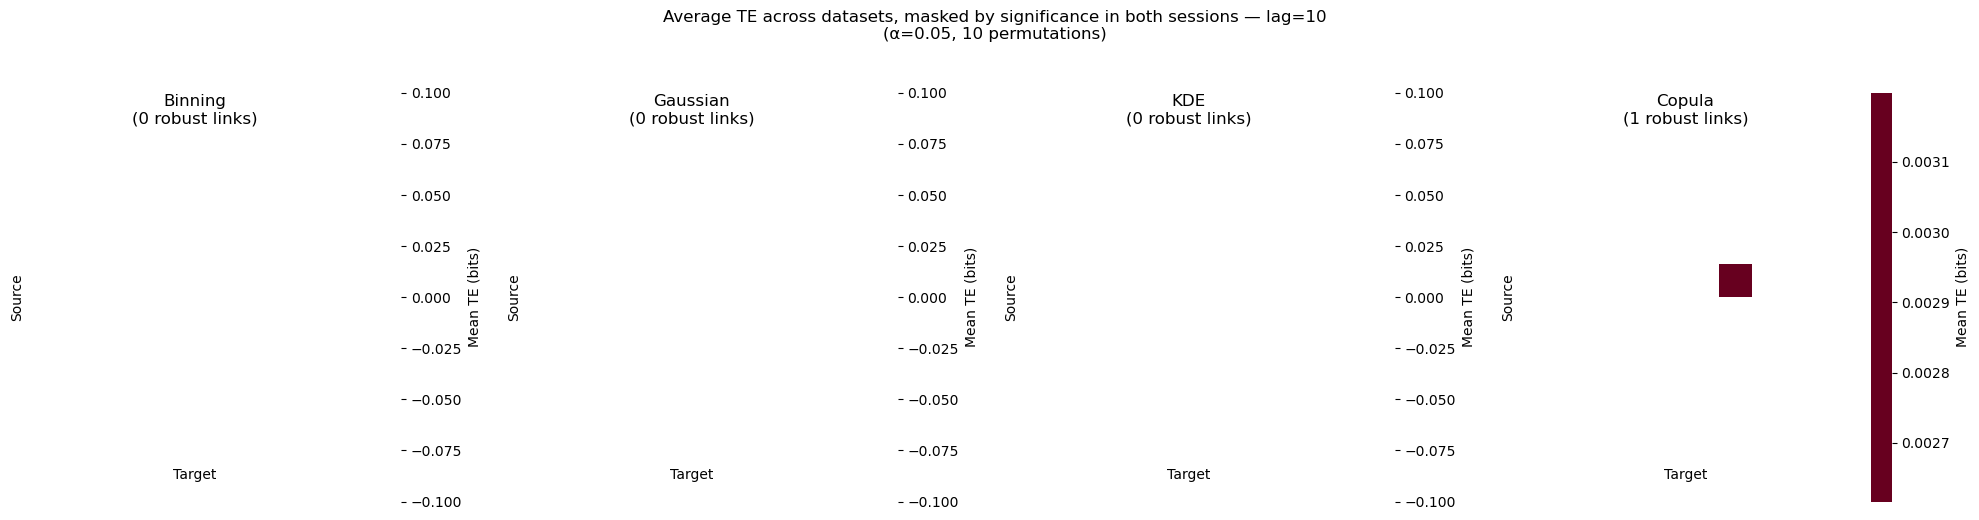

In [40]:
# LAG SWEEP — only robust average-TE heatmaps per method
lags_to_test = [1, 2, 5, 10]

for lag in lags_to_test:
    print(f"\n{'='*60}")
    print(f"LAG = {lag}")
    print(f"{'='*60}")

    # --------------------------------------------------
    # Recompute real TE matrices for this lag
    # --------------------------------------------------
    TE_real_gauss_1  = nlib.transfer_entropy_matrix(data1_mat,                   method="gauss", lag=lag)
    TE_real_gauss_2  = nlib.transfer_entropy_matrix(data2_mat,                   method="gauss", lag=lag)

    TE_real_copula_1 = nlib.transfer_entropy_matrix(data1_mat,                   method="gc",   lag=lag)
    TE_real_copula_2 = nlib.transfer_entropy_matrix(data2_mat,                   method="gc",   lag=lag)

    TE_real_bin_1    = nlib.transfer_entropy_matrix(data1_mat,                   method="binning",  lag=lag, n_bins=nbins)
    TE_real_bin_2    = nlib.transfer_entropy_matrix(data2_mat,                   method="binning",  lag=lag, n_bins=nbins)

    TE_real_kde_1    = nlib.transfer_entropy_matrix(data1_mat[:kde_regions, :],  method="kde",      lag=lag)
    TE_real_kde_2    = nlib.transfer_entropy_matrix(data2_mat[:kde_regions, :],  method="kde",      lag=lag)

    # --------------------------------------------------
    # Permutation tests
    # --------------------------------------------------
    sig_gauss_1,  _, _ = permutation_test_TE(
        data1_mat, TE_real_gauss_1,
        method="gauss", n_perms=n_perms, alpha=alpha, fdr=False, lag=lag
    )
    sig_gauss_2,  _, _ = permutation_test_TE(
        data2_mat, TE_real_gauss_2,
        method="gauss", n_perms=n_perms, alpha=alpha, fdr=False, lag=lag
    )

    sig_copula_1, _, _ = permutation_test_TE(
        data1_mat, TE_real_copula_1,
        method="gc", n_perms=n_perms, alpha=alpha, fdr=False, lag=lag
    )
    sig_copula_2, _, _ = permutation_test_TE(
        data2_mat, TE_real_copula_2,
        method="gc", n_perms=n_perms, alpha=alpha, fdr=False, lag=lag
    )

    sig_bin_1, _, _ = permutation_test_TE(
        data1_mat, TE_real_bin_1,
        method="binning", n_perms=n_perms, alpha=alpha, fdr=False, lag=lag, n_bins=nbins
    )
    sig_bin_2, _, _ = permutation_test_TE(
        data2_mat, TE_real_bin_2,
        method="binning", n_perms=n_perms, alpha=alpha, fdr=False, lag=lag, n_bins=nbins
    )

    sig_kde_1, _, _ = permutation_test_TE(
        data1_mat[:kde_regions, :], TE_real_kde_1,
        method="kde", n_perms=n_perms, alpha=alpha, fdr=False, lag=lag
    )
    sig_kde_2, _, _ = permutation_test_TE(
        data2_mat[:kde_regions, :], TE_real_kde_2,
        method="kde", n_perms=n_perms, alpha=alpha, fdr=False, lag=lag
    )

    # --------------------------------------------------
    # Methods list
    # --------------------------------------------------
    methods_grid = [
        (sig_bin_1,    sig_bin_2,    TE_real_bin_1,    TE_real_bin_2,    "Binning"),
        (sig_gauss_1,  sig_gauss_2,  TE_real_gauss_1,  TE_real_gauss_2,  "Gaussian"),
        (sig_kde_1,    sig_kde_2,    TE_real_kde_1,    TE_real_kde_2,    "KDE"),
        (sig_copula_1, sig_copula_2, TE_real_copula_1, TE_real_copula_2, "Copula"),
    ]

    # --------------------------------------------------
    # Plot only robust average TE heatmaps
    # --------------------------------------------------
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))

    for ax, (sig1, sig2, te1, te2, name) in zip(axes, methods_grid):
        robust = sig1 & sig2
        np.fill_diagonal(robust, False)

        avg_te = np.where(robust, (te1 + te2) / 2, np.nan)

        sns.heatmap(
            avg_te,
            ax=ax,
            cmap="RdBu_r",
            center=0,
            square=True,
            cbar_kws={"label": "Mean TE (bits)"},
            xticklabels=False,
            yticklabels=False
        )

        ax.set_title(f"{name}\n({robust.sum()} robust links)")
        ax.set_xlabel("Target")
        ax.set_ylabel("Source")

    plt.suptitle(
        f"Average TE across datasets, masked by significance in both sessions — lag={lag}\n"
        f"(α={alpha}, {n_perms} permutations)",
        y=1.03
    )
    plt.tight_layout()
    plt.show()